In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [ ]:
data = 'UCI_HAR_Dataset/UCI HAR Dataset'

def load_dataset(data):
    try:
        train_path = os.path.join(data, 'train')
        test_path = os.path.join(data, 'test')

        X_train = np.loadtxt(os.path.join(train_path, 'X_train.txt'))
        y_train = np.loadtxt(os.path.join(train_path, 'y_train.txt')).astype(int) - 1

        X_test = np.loadtxt(os.path.join(test_path, 'X_test.txt'))
        y_test = np.loadtxt(os.path.join(test_path, 'y_test.txt')).astype(int) - 1

        print("Dataset Information:")
        print(f"Training 11s Shape: {X_train.shape}")
        print(f"Training Labels Shape: {y_train.shape}")
        print(f"Testing 11s Shape: {X_test.shape}")
        print(f"Testing Labels Shape: {y_test.shape}")

        return X_train, y_train, X_test, y_test

    except Exception as e:
        print(f"Error loading dataset: {e}")
        raise

In [ ]:
def preprocess_data(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train = X_train.reshape(-1, 51, 11)
    X_test = X_test.reshape(-1, 51, 11)

    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)

    print("Preprocessed Data Information:")
    print(f"Training 11s Shape: {X_train.shape}")
    print(f"Training Labels Shape: {y_train.shape}")
    print(f"Testing 11s Shape: {X_test.shape}")
    print(f"Testing Labels Shape: {y_test.shape}")

    return X_train, y_train, X_test, y_test

In [ ]:
def build_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(128, 3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(256, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),

        LSTM(128, return_sequences=True),
        LSTM(64),

        Dropout(0.5),

        Dense(100, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test):
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=1
    )

    return history

In [ ]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')

    plt.show()

def evaluate_model(model, X_test, y_test):
    loss, accuracy = model.evaluate(X_test, y_test)

    print("Model Performance:")
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    print("Detailed Classification Report:")
    print(classification_report(y_true_classes, y_pred_classes))

    plot_confusion_matrix(y_true_classes, y_pred_classes)

    return loss, accuracy

Dataset Information:
Training Features Shape: (7352, 561)
Training Labels Shape: (7352,)
Testing Features Shape: (2947, 561)
Testing Labels Shape: (2947,)
Preprocessed Data Information:
Training Features Shape: (7352, 51, 11)
Training Labels Shape: (7352, 6)
Testing Features Shape: (2947, 51, 11)
Testing Labels Shape: (2947, 6)


C:\Users\Computec\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 51, 128)             │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 51, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 25, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 25, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 25, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 12, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 12, 128)             │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │           6,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             606 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 358,082 (1.37 MB)

 Trainable params: 357,314 (1.36 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.5480 - loss: 1.1444 - val_accuracy: 0.7710 - val_loss: 0.5835 - learning_rate: 5.0000e-04
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9224 - loss: 0.3155 - val_accuracy: 0.8935 - val_loss: 0.4202 - learning_rate: 5.0000e-04
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9586 - loss: 0.2087 - val_accuracy: 0.9250 - val_loss: 0.3335 - learning_rate: 5.0000e-04
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9783 - loss: 0.1396 - val_accuracy: 0.8812 - val_loss: 0.4996 - learning_rate: 5.0000e-04
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9783 - loss: 0.1377 - val_accuracy: 0.9030 - val_loss: 0.4809 - learning_rate: 5.0000e-04
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9878 - loss: 0.1031 - val_accuracy: 0.8385 - val_loss: 0.9529 - learning_rate: 5.0000e-04
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/st

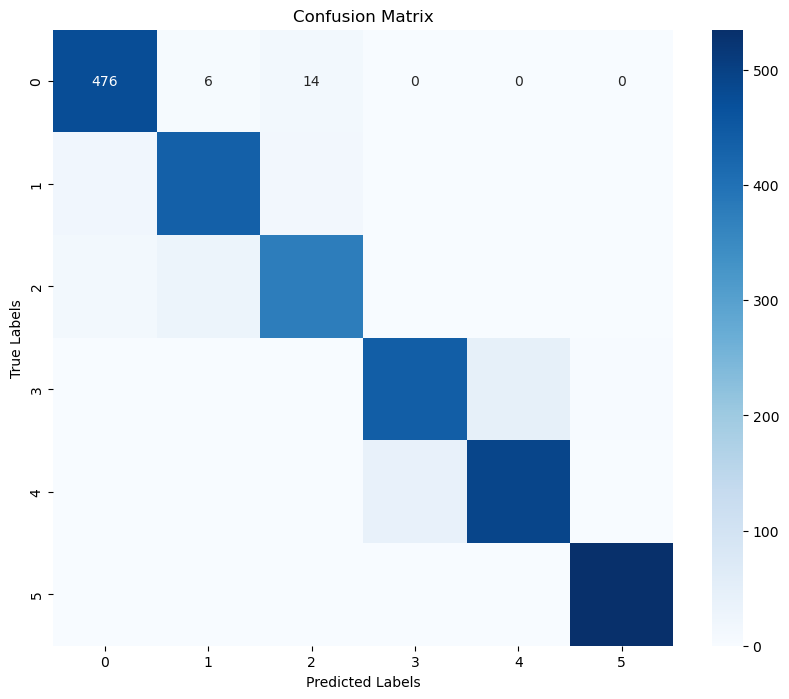

In [ ]:
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_dataset(data)

X_train, y_train, X_test, y_test = preprocess_data( X_train_raw, y_train_raw, X_test_raw, y_test_raw)

model = build_model(input_shape=(51, 11), num_classes=y_train.shape[1])

history = train_model(model, X_train, y_train, X_test, y_test)

loss, accuracy = evaluate_model(model, X_test, y_test)

In [ ]:
history = train_model(model, X_train, y_train, X_test, y_test)

model.save("har_model.h5")